[2026-07-07 23:06:47] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-07 23:06:48] [info     ] 开始构建训练集                        train_end='2023-12-31 23:59:59' train_start='2022-01-01 00:00:00'
[2026-07-07 23:06:48] [info     ] build_features 开始              end='2023-12-31 23:59:59' start='2022-01-01 00:00:00'
[2026-07-07 23:07:11] [info     ] 量价数据查询完成                       elapsed=23.19 n_instruments=2214 rows=1151470
[2026-07-07 23:07:11] [info     ] 标签计算完成                         elapsed=23.27
[2026-07-07 23:07:11] [info     ] 滞后特征计算完成                       elapsed=0.26 n_features=13
[2026-07-07 23:07:11] [info     ] build_features 结束              rows=1027068 total_elapsed=23.65
[2026-07-07 23:07:12] [info     ] 训练集构建完成                        samples=1021345
[2026-07-07 23:07:12] [info     ] 验证集切分                          cutoff_date=2023-08-08 train_s=810702 val_s=210643
[2026-07-08 00:17:08] [info     ] 模型训练完成                         best_iter=200 elapsed=

时段,IC
2024-01-15~2024-02-08,0.0259
2024-09-24~2024-10-08,0.0234

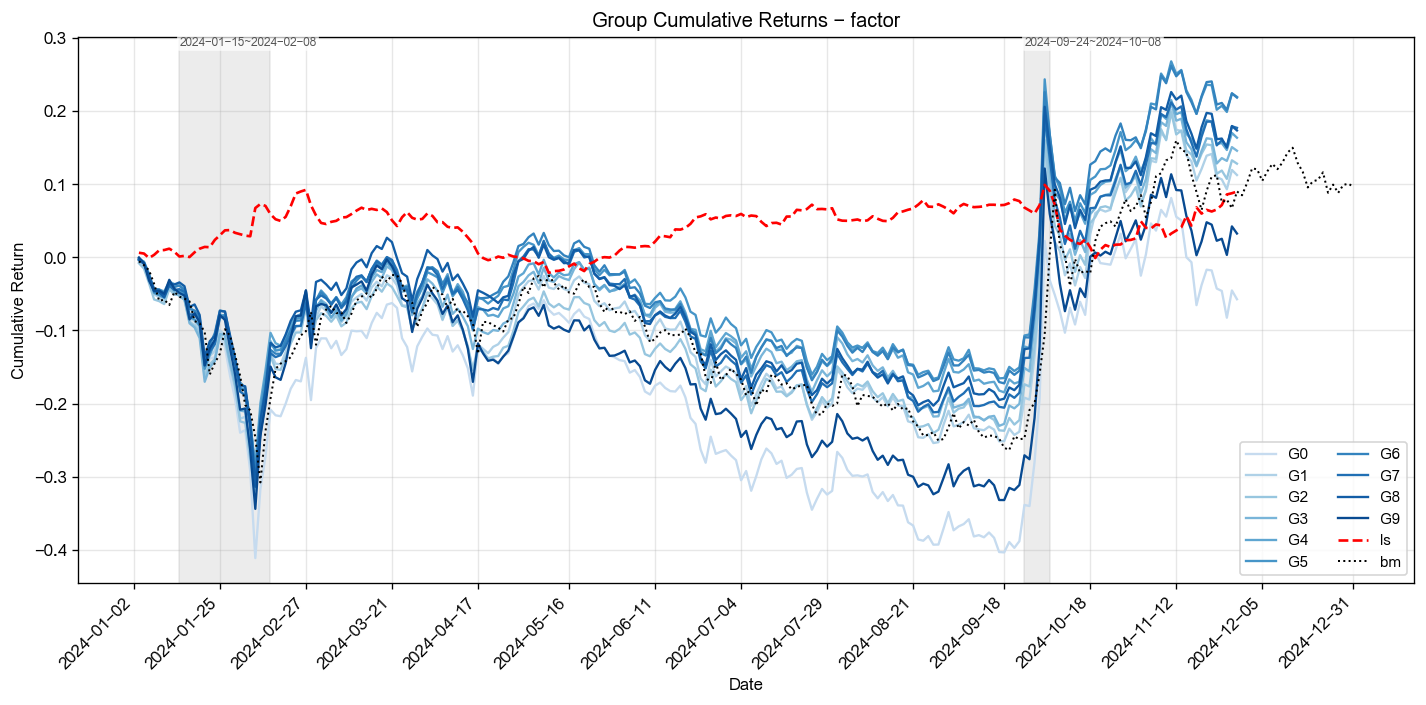
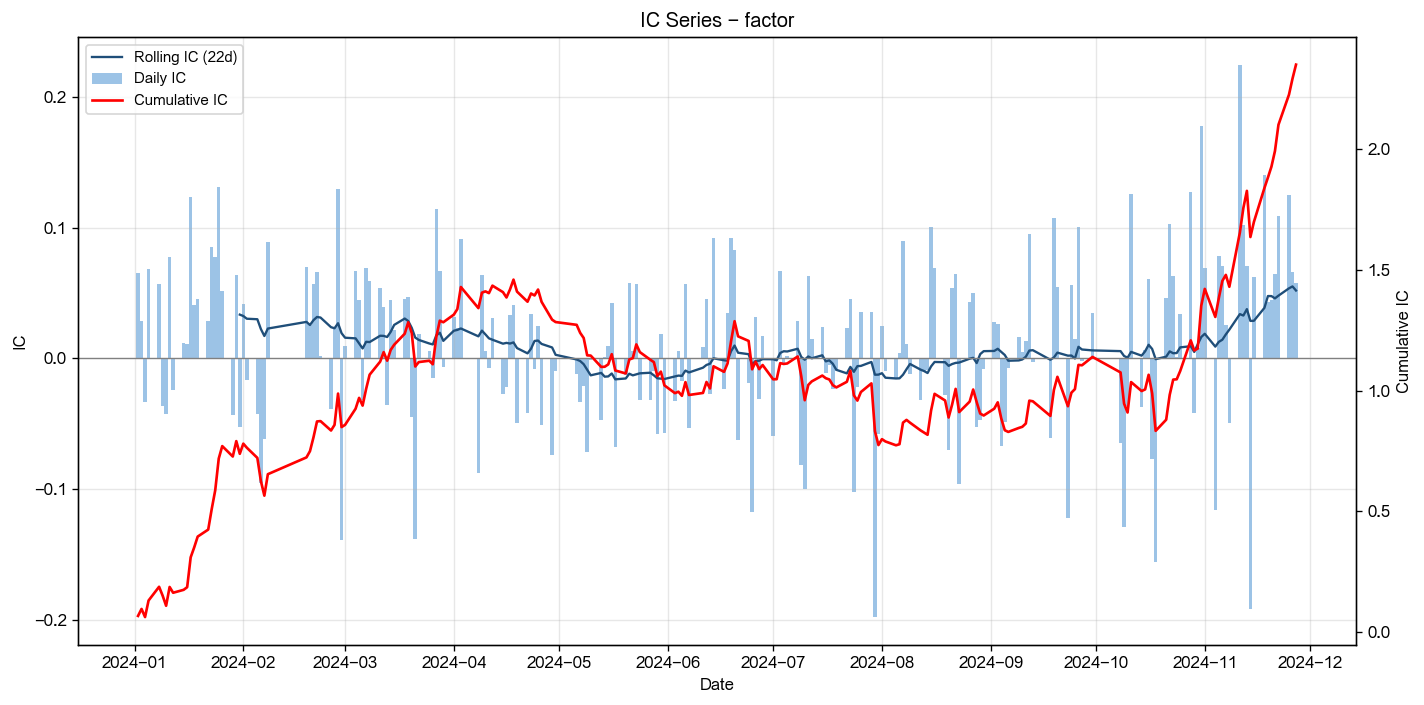
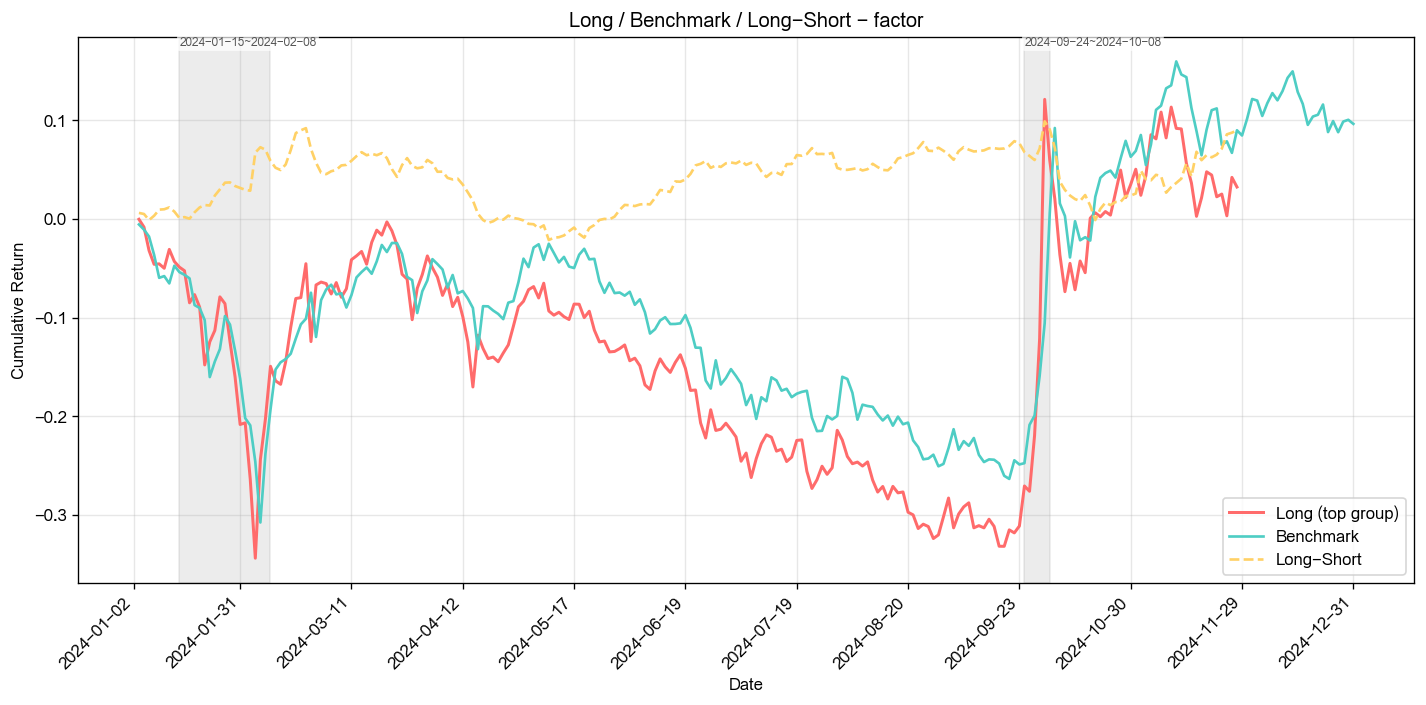
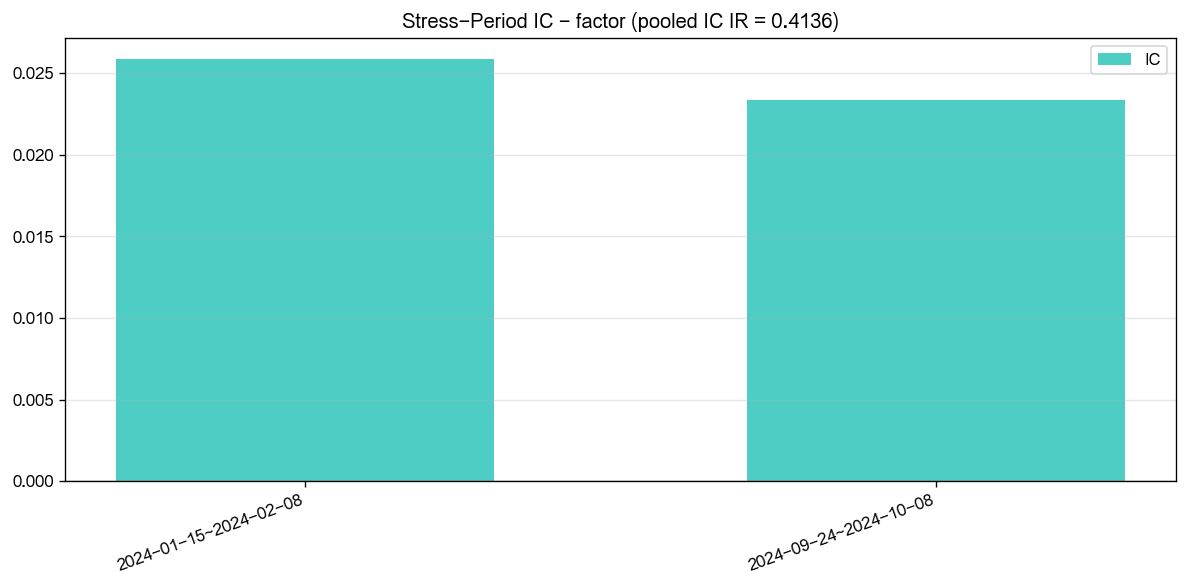
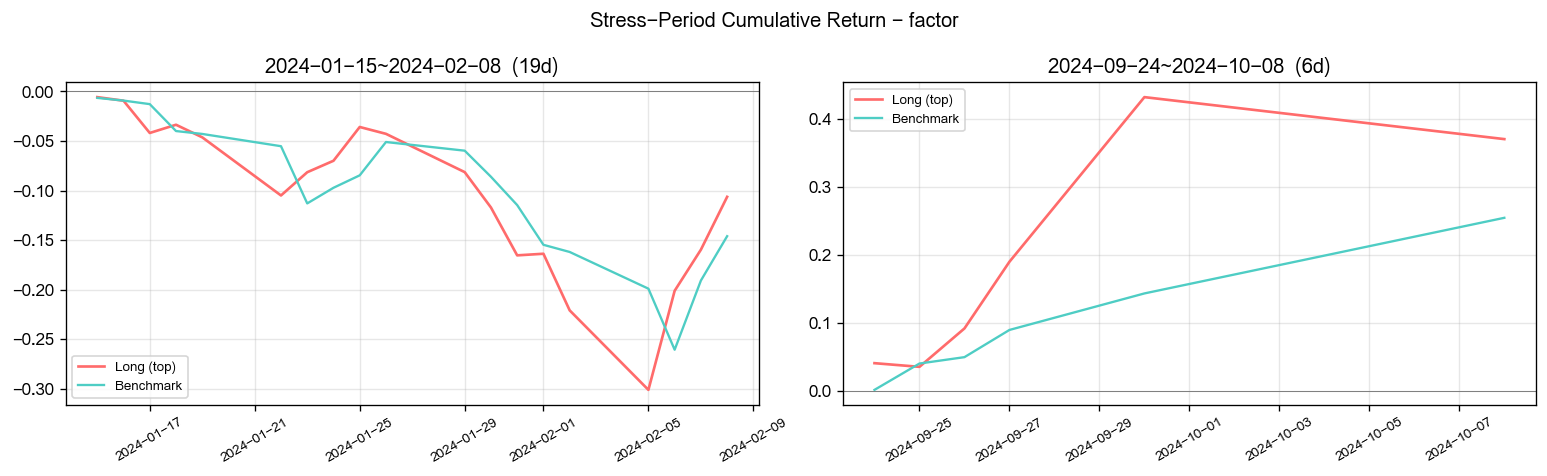

[2026-07-08 00:20:49] [info     ] ========== 因子池回归 ==========
[2026-07-08 00:20:50] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-08 00:20:50] [info     ] 获取收益率数据, 耗时: 1.1856 秒
[2026-07-08 00:20:52] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.9005 秒
[2026-07-08 00:20:52] [info     ] 统计 回归结果, 耗时: 0.1121 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9552,0.0439,0.0225,1.0000
2,amount,1.6819,0.0176,0.0105,0.9000
3,netflow_amount_rate_main,1.5177,0.0100,0.0066,1.0000
4,gross_profit_rate_ttm,1.5000,0.0069,0.0046,1.0000
5,netflow_amount_main,1.4937,0.0251,0.0168,1.0000
6,cci_14,1.4556,0.0337,0.0232,1.0000
7,net_profit_rate_ttm,1.4534,0.0040,0.0028,0.8000
8,pb,1.4233,0.0097,0.0068,1.0000
9,bias_20,1.3646,0.0286,0.0209,0.9000
10,factor,1.3452,0.0092,0.0068,1.0000

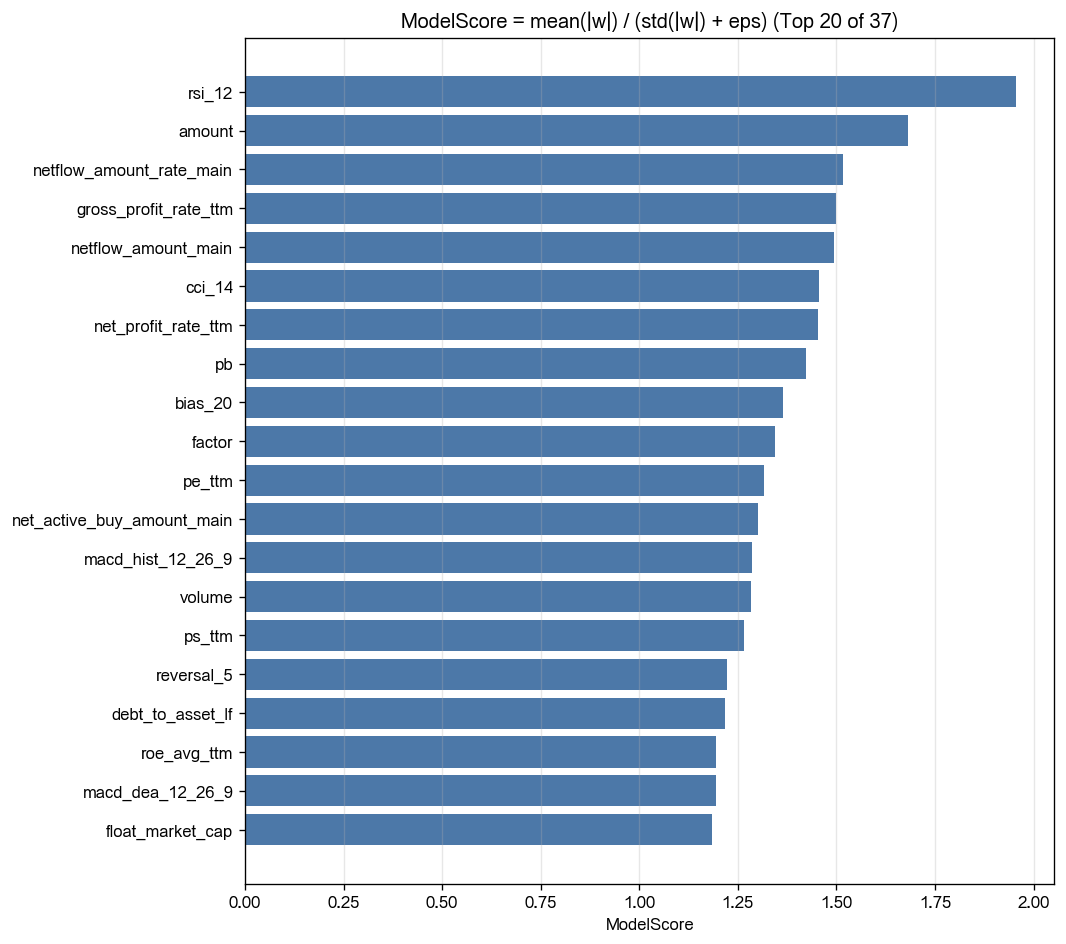
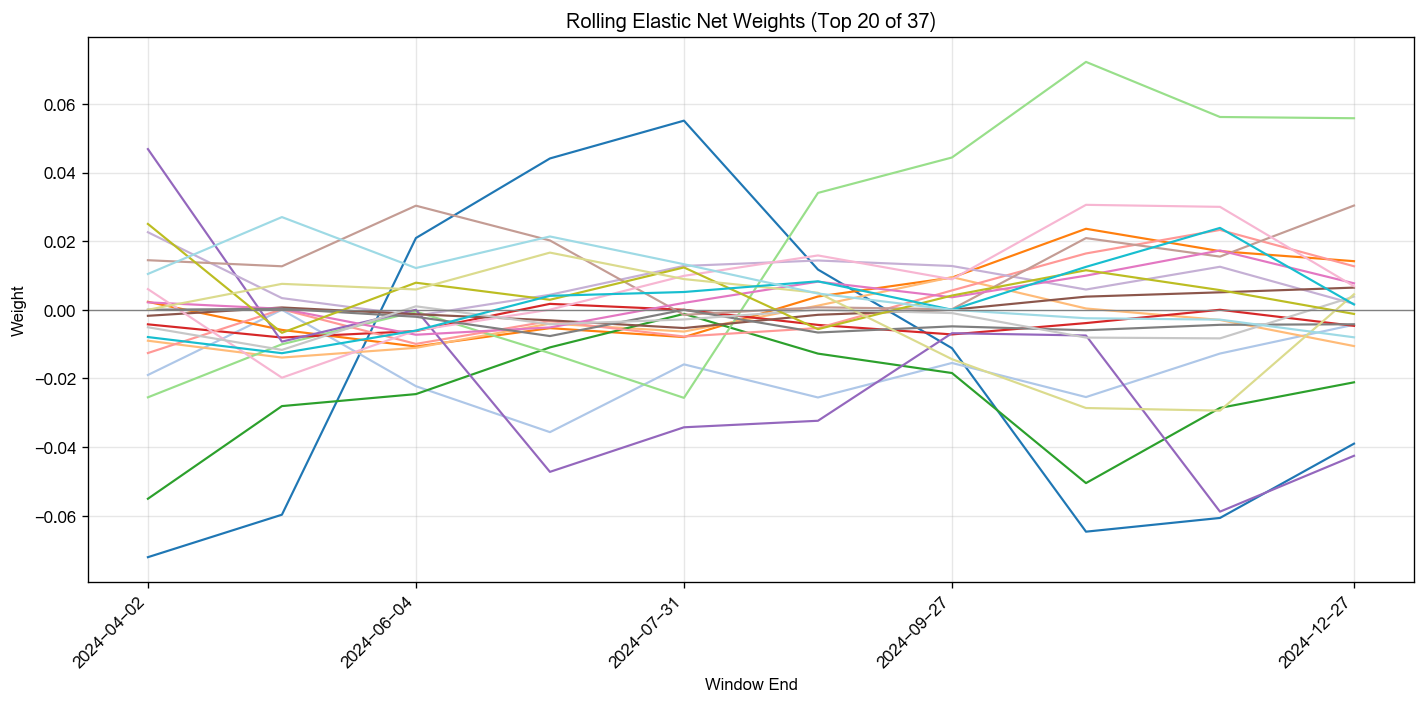
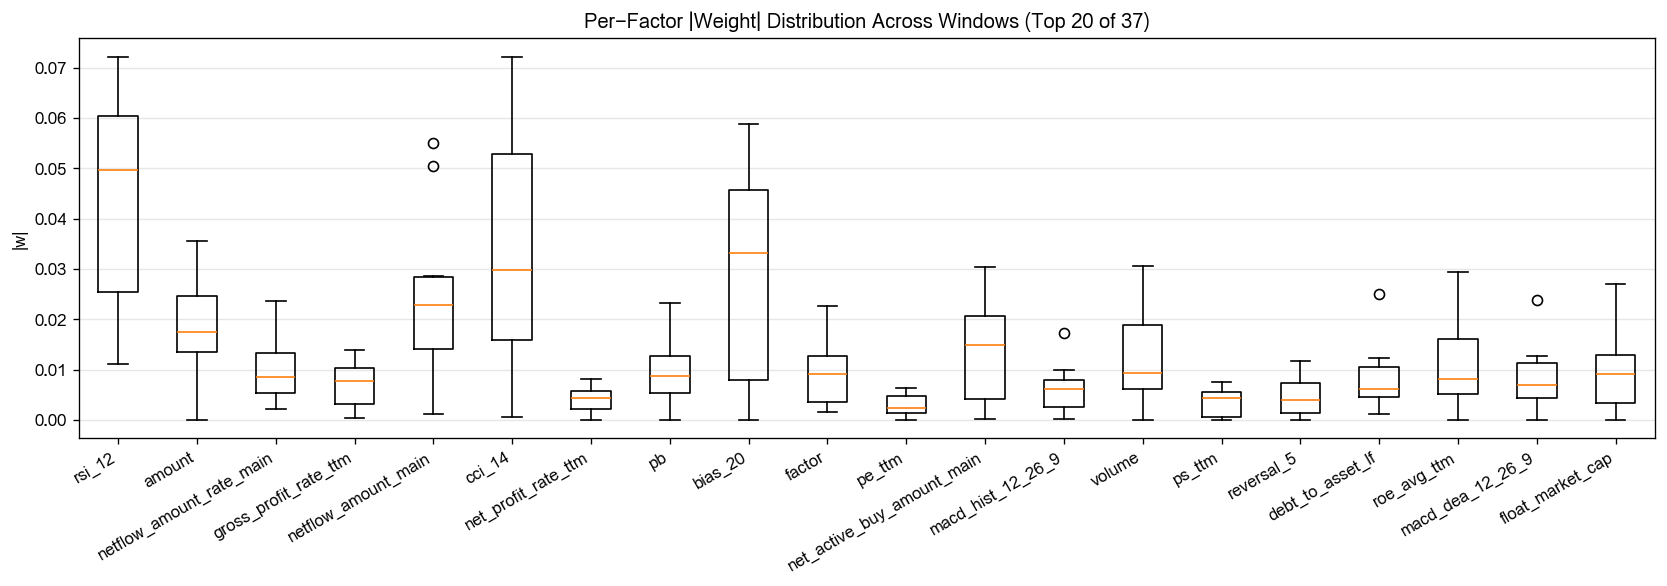
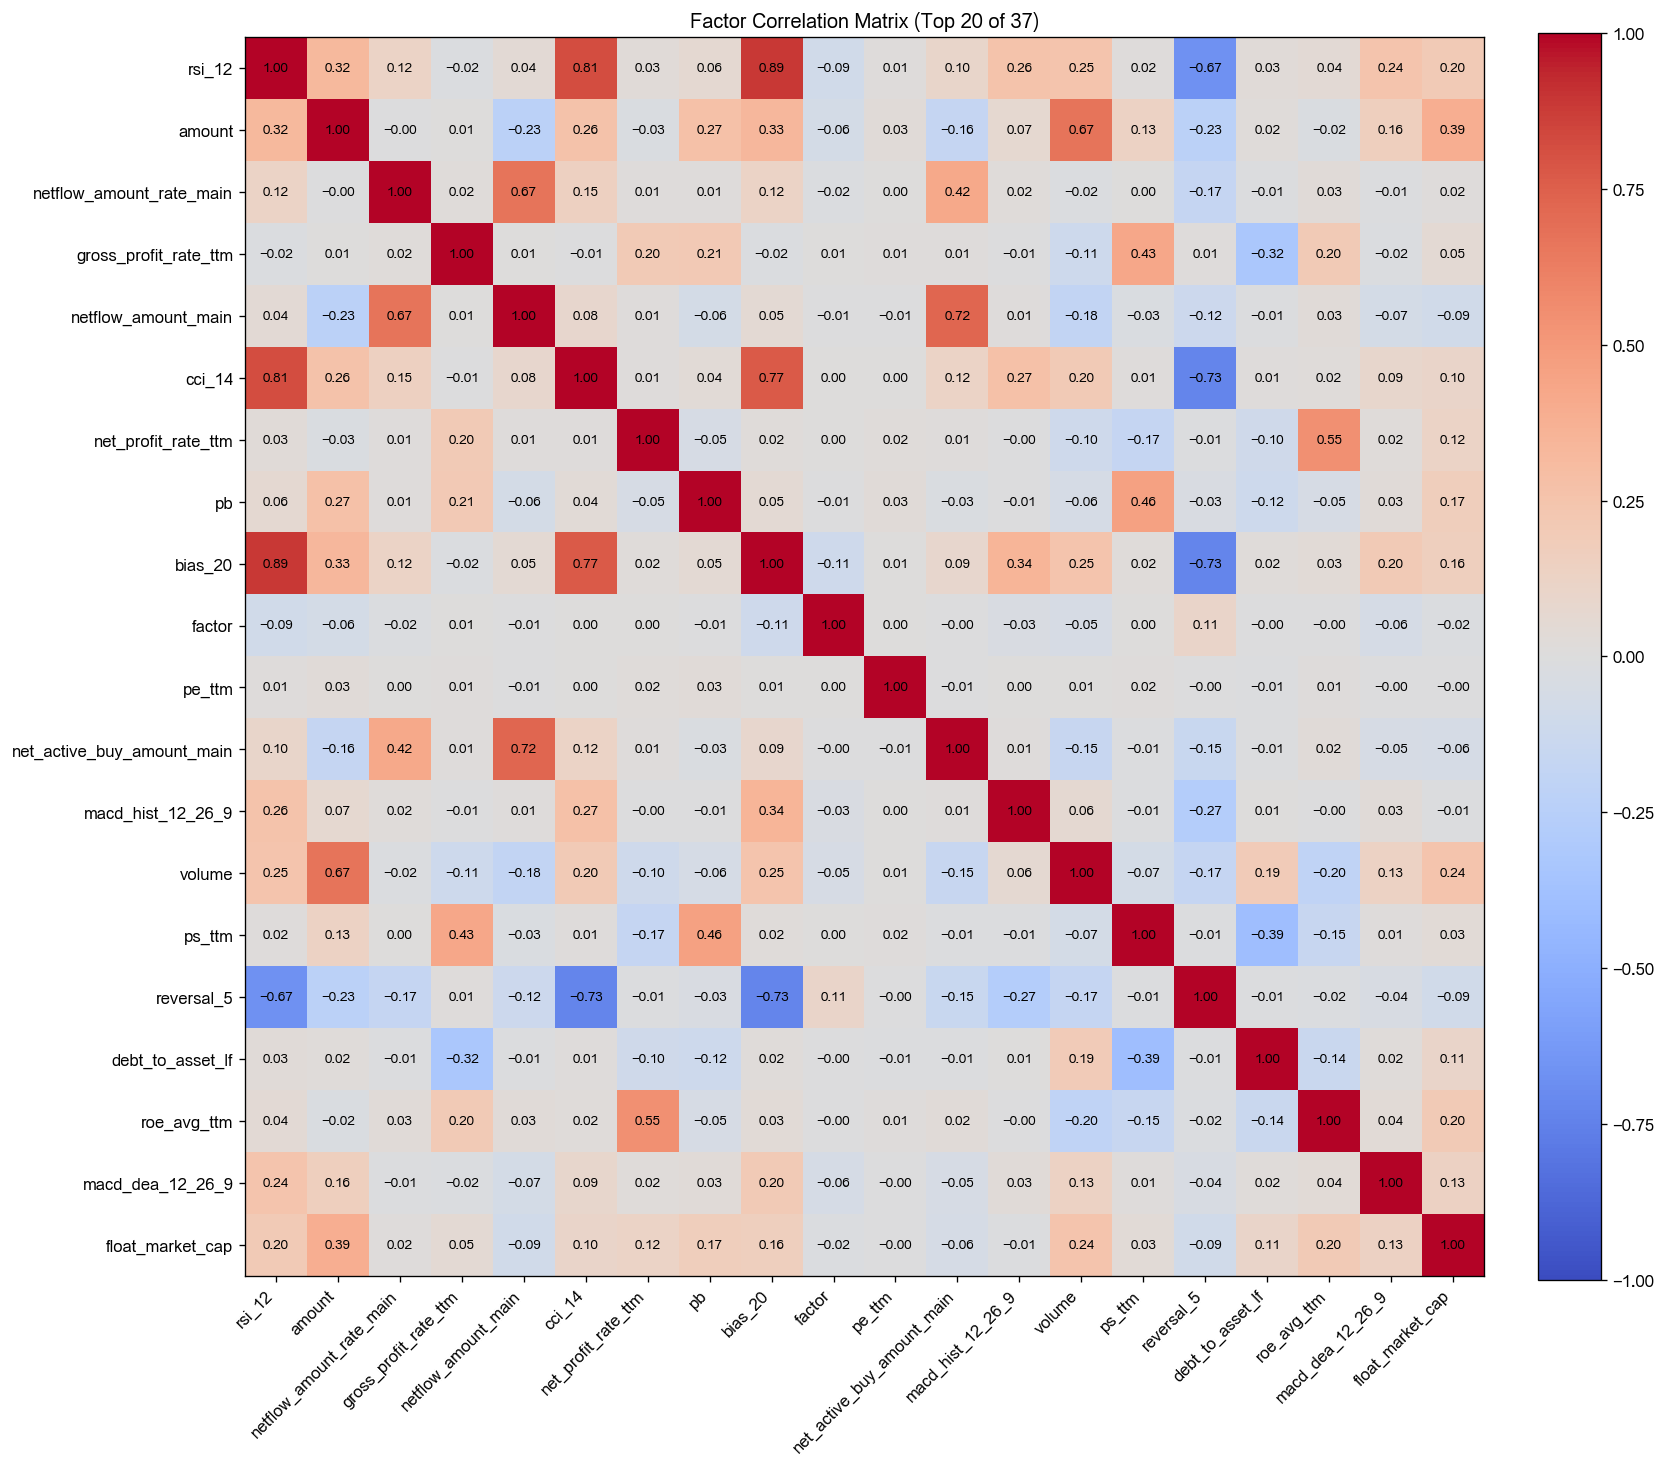

[2026-07-08 00:20:57] [warning  ] 返回的Outputs实例(size=35368029) 大于 64K, 将不会被缓存
[2026-07-08 00:20:57] [info     ] bigalpha_eval.v4 运行完成 [204.307s].


In [1]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数（XGBoost Alpha360 精简版）

    ⚠️ 赛制约定（重要）:
        评测时平台只会替换 datasources / start_date / end_date 三个入参,且 start_date~end_date
        指向的是【测试集区间】。因此训练区间必须在代码里写死（见下方 TRAIN_START/TRAIN_END）,
        本函数只用写死的训练区间拟合模型,再用平台传入的测试区间做【样本外预测】。
        切勿用传入的 start_date/end_date 训练模型——那等于在测试集上训练,既是数据泄漏, 也无法体现因子真实的样本外能力。
        后期会审查这类问题

    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}，平台会在公榜/私榜自动切换。
                            可用逻辑名: "bar1m" -> 分钟 K 线表, "financial" -> 财务数据表
        start_date (str): 测试集开始时间（平台注入）
        end_date (str):   测试集结束时间（平台注入）

    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog

    logger = structlog.get_logger()

    # ============================================================
    # 训练区间：写死，不随平台入参变化
    # ============================================================
    TRAIN_START = '2022-01-01 00:00:00'
    TRAIN_END   = '2023-12-31 23:59:59'

    # Alpha360 风格 close 滞后比：历史收盘价 / 当前收盘价
    # 精选 13 个关键 lag（vol/amt 滞后比与 label 相关≈0，已剔除）
    CLOSE_LAGS = [1, 2, 3, 5, 10, 20, 27, 31, 42, 54, 55, 57, 59]
    feature_cols = [f'close_lag_{lag}' for lag in CLOSE_LAGS]

    # ============================================================
    # 特征工程：close 滞后比 + 标签
    # ============================================================
    def build_features(bar1m_table, sd, ed):
        t0 = time.time()
        logger.info("build_features 开始", start=str(sd), end=str(ed))

        # ----- 量价数据（需要 90 天缓冲算滞后特征，仅查 close 提速度）-----
        t1 = time.time()
        price_start = pd.to_datetime(sd) - pd.Timedelta(days=90)
        price_sql = f"""
            SELECT
                date_trunc('day', date)::DATE AS trading_day,
                instrument,
                ARG_MAX(close, date) AS close
            FROM {bar1m_table}
            GROUP BY trading_day, instrument
            ORDER BY trading_day, instrument
        """
        price = dai.query(price_sql, filters={'date': [price_start, ed]}).df().rename(columns={'trading_day': 'date'})
        price['date'] = pd.to_datetime(price['date'])
        price = price.sort_values(['instrument', 'date']).reset_index(drop=True)
        logger.info("量价数据查询完成", rows=len(price), n_instruments=price['instrument'].nunique(),
                    elapsed=round(time.time() - t1, 2))

        # 数值清洗
        price['close'] = pd.to_numeric(price['close'], errors='coerce')
        price['close'] = price['close'].replace([np.inf, -np.inf], np.nan)

        # ----- 标签：未来 1 日收益 -----
        g = price.groupby('instrument', group_keys=False)['close']
        price['label'] = g.shift(-1) / price['close'] - 1
        price['label'] = price['label'].replace([np.inf, -np.inf], np.nan)
        logger.info("标签计算完成", elapsed=round(time.time() - t1, 2))

        # ----- Alpha360 滞后特征：close.shift(lag) / close -----
        t2 = time.time()
        grp = price.groupby('instrument')
        for lag in CLOSE_LAGS:
            c = f'close_lag_{lag}'
            price[c] = grp['close'].shift(lag) / price['close']
            price[c] = price[c].replace([np.inf, -np.inf], np.nan)
        logger.info("滞后特征计算完成", n_features=len(CLOSE_LAGS),
                    elapsed=round(time.time() - t2, 2))

        # 截断到目标区间 [sd, ed]
        price = price[(price['date'] >= pd.to_datetime(sd)) & (price['date'] <= pd.to_datetime(ed))]
        logger.info("build_features 结束", rows=len(price), total_elapsed=round(time.time() - t0, 2))
        return price.reset_index(drop=True)

    # ============================================================
    # 第 1 步：用【写死的训练区间】拟合模型
    # ============================================================
    logger.info("开始构建训练集", train_start=TRAIN_START, train_end=TRAIN_END)
    train_df = build_features('bigalpha_2026_stock_bar1m', TRAIN_START, TRAIN_END)
    train_df['label'] = train_df['label'].replace([np.inf, -np.inf], np.nan)
    train_df = train_df.dropna(subset=['label'])
    logger.info("训练集构建完成", samples=len(train_df))

    # 切验证集：按时间顺序，最后 20% 用于早停
    train_dates = sorted(train_df['date'].unique())
    val_cutoff = train_dates[int(len(train_dates) * 0.8)]
    val_mask = train_df['date'] >= val_cutoff
    train_mask = ~val_mask
    logger.info("验证集切分", train_s=int(train_mask.sum()), val_s=int(val_mask.sum()),
                cutoff_date=str(val_cutoff.date()))

    # 模型训练
    t_fit = time.time()
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.0421,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=50,
        reg_alpha=5.0, reg_lambda=10.0,
        tree_method='hist', n_jobs=-1, random_state=42,
        early_stopping_rounds=30,
    )
    model.fit(
        train_df.loc[train_mask, feature_cols], train_df.loc[train_mask, 'label'],
        eval_set=[(train_df.loc[val_mask, feature_cols], train_df.loc[val_mask, 'label'])],
        verbose=False,
    )
    logger.info("模型训练完成", elapsed=round(time.time() - t_fit, 2), best_iter=model.best_iteration)

    # ============================================================
    # 第 2 步：用【平台传入的测试区间】做样本外预测，预测值即为因子
    # ============================================================
    logger.info("开始构建测试集并预测")
    bar1m_table = datasources['bar1m']
    test_df = build_features(bar1m_table, start_date, end_date)
    test_df['factor'] = model.predict(test_df[feature_cols])

    # ============================================================
    # 第 3 步：对齐中证 1000 成分股并输出
    # ============================================================
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    result = pd.merge(test_df[['date', 'instrument', 'factor']], stk_pool,
                      how='inner', on=['date', 'instrument'])
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result = result.dropna(subset=['factor']).reset_index(drop=True)[['date', 'instrument', 'factor']]
    logger.info("因子构建完成", rows=len(result))
    return result


if __name__ == '__main__':
    from bigmodule import M
    import structlog
    import dai
    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }
    # 本地用这段区间模拟「平台注入的测试集区间」（训练区间已在 main 内写死）
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )